In [ ]:
from sklearn.datasets import load_digits, load_breast_cancer, load_wine, load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

dataset = load_digits()

target_names = dataset.target_names.astype(str)

X = dataset.data
y = dataset.target

scaler_std = StandardScaler()
#scaler_MinMax = MinMaxScaler()

X_StandardScaler = scaler_std.fit_transform(X)
#X_MinMax = scaler_MinMax.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

forest_model = RandomForestClassifier(n_estimators=100)
forest_model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:

def print_res(y_test, y_pred):
  accuracy = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred, average='weighted')
  preccision = precision_score(y_test, y_pred, average='weighted')
  recall = recall_score(y_test, y_pred, average='weighted')
  print(f"""
  accuracy    = {accuracy}
  f1          = {f1}
  preccision  = {preccision}
  recall      = {recall}
  """)
  print(classification_report(y_test, y_pred, target_names=target_names))

In [ ]:
print("---SVM---")
y_pred_svm = svm_model.predict(X_test)
print_res(y_test, y_pred_svm)

print("\n\n---RandomForest---")
y_pred_forest = forest_model.predict(X_test)
print_res(y_test, y_pred_forest)

---SVM---

  accuracy    = 0.9814814814814815
  f1          = 0.9814469253287095
  preccision  = 0.9816252906835445
  recall      = 0.9814814814814815   
  
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        57
           1       0.96      1.00      0.98        51
           2       1.00      1.00      1.00        56
           3       0.98      0.94      0.96        48
           4       0.98      0.98      0.98        55
           5       0.98      0.98      0.98        55
           6       1.00      1.00      1.00        57
           7       0.98      1.00      0.99        59
           8       0.95      0.96      0.96        57
           9       0.98      0.96      0.97        45

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



---RandomForest---

  accuracy    = 0.9518518518518518
  f1          = 0.951859936

In [ ]:


def cm(y_test, y_pred, model_name):
  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
  disp.plot(cmap=plt.cm.Blues)
  plt.title(f"Confusion Matrix - {model_name}")
  plt.show()

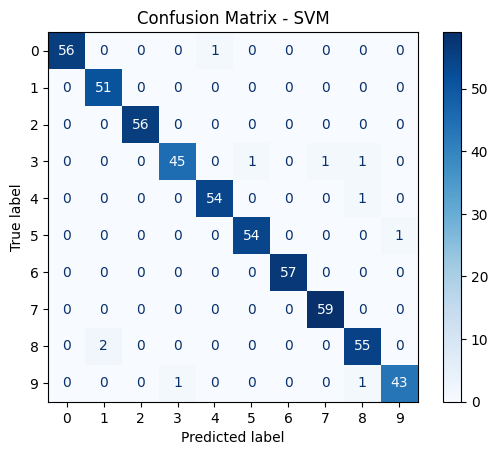

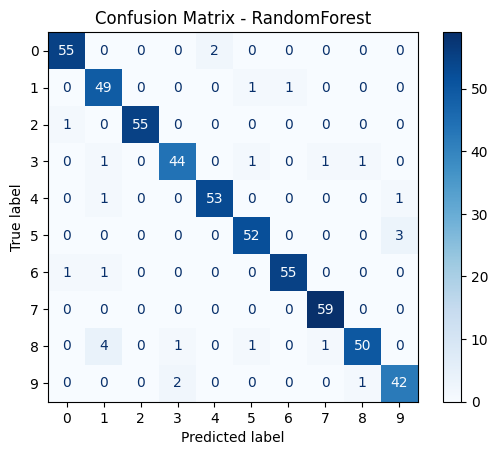

In [ ]:
cm(y_test, y_pred_svm, "SVM")
cm(y_test, y_pred_forest, "RandomForest")